## Imports

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import mesmer
import model
import model_analysis

import importlib
import matplotlib.pyplot as plt
import xarray as xr

import numpy as np

import cartopy.crs as ccrs
from scipy.stats import beta



## Load Data

In [2]:
is_local_data = False
Month_idx = 4
safe = True
start = None
end = None
max_depth = 3

In [3]:
raw_mrsol_for_mean = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=1)

raw_mrsol_for_var = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=2)

raw_mrsol_for_skew = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=3)

In [4]:
raw_mrsol_empirical_maximas_mean = raw_mrsol_for_mean.max("time")
raw_mrsol_empirical_maximas_var = raw_mrsol_for_var.max("time")
raw_mrsol_empirical_maximas_skew = raw_mrsol_for_skew.max("time")

raw_mrsol_empirical_maximas = xr.concat([raw_mrsol_empirical_maximas_mean,raw_mrsol_empirical_maximas_var,raw_mrsol_empirical_maximas_skew],dim="sets").max("sets")

approx_maximas = raw_mrsol_empirical_maximas.copy(deep=True)
approx_maximas["mrsol"] = (raw_mrsol_empirical_maximas["mrsol"] * 1.1).clip(min=1e-5)


In [5]:
tas_ds = model.loading.load_data_set(var = "tas", local = is_local_data, run_idx=1)
pr_ds = model.loading.load_data_set(var = "pr", local = is_local_data, run_idx=1)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=Month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=Month_idx)

raw_input_for_mean = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.loading.load_data_set(var = "tas", local = is_local_data, run_idx=2)
pr_ds = model.loading.load_data_set(var = "pr", local = is_local_data, run_idx=2)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=Month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=Month_idx)

raw_input_for_var = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")





tas_ds = model.loading.load_data_set(var = "tas", local = is_local_data, run_idx=5)
pr_ds = model.loading.load_data_set(var = "pr", local = is_local_data, run_idx=5)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=Month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=Month_idx)

raw_input_for_test = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


### functions to bring the data in shape

In [6]:
def shape_target(ds, maximas):
    ds = ds.clip(min = 0)
    ds = ds/maximas
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx).isel(depth=slice(0, max_depth))
    return ds

In [7]:
def mask_stack_target(ds):
    masked_ds, chunk_mask, detail_mask= model.mask.mask_nonpositiv_height_chunks(ds.drop_vars("depth_bnds"))
    ds = mesmer.grid.stack_lat_lon(masked_ds)
    ds = ds.transpose("gridcell","time", "depth")
    return ds,chunk_mask, detail_mask

In [8]:
def shape_input(ds, chunk_mask):
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx)
    ds = model.mask.mask_mask(ds,chunk_mask)
    ds = mesmer.grid.stack_lat_lon(ds)
    return ds

    

In [9]:
#The chunk_mask schould all be the same, this is important that there are no shape problems in the regressions, you can test this with  
#(chunk_mask != chunk_mask_var).sum()etc,
#The chunk_mask is used, that the regression can predict a depth.size vector at each gridcell, the masks: detail_mask_mean, detail_mask_var and detail_mask_test are later used to determan which points are real predictions and witch where just placeholders to let the regression run smoothly.

### Linear Regression of the mean

In [10]:
mean_target_noneT = shape_target(raw_mrsol_for_mean, approx_maximas)
mean_target_noneT, chunk_mask, detail_mask = mask_stack_target(mean_target_noneT)
mean_target = model.transform.Logit_Transform_ds(mean_target_noneT)
mean_target_da = mean_target.mrsol

In [11]:
mean_predictors = shape_input(raw_input_for_mean,chunk_mask)

In [12]:
LinReg_mean = model.stats._parallel_linear_regression.ParLinearRegression()

In [13]:
LinReg_mean.fit(predictors=mean_predictors, target=mean_target_da,location_dim="gridcell", regr_dim="time")

### Compute Residuals for the variance

In [14]:
var_target_noneT = shape_target(raw_mrsol_for_var, approx_maximas)
var_target_noneT, chunk_mask_var, detail_mask_var= mask_stack_target(var_target_noneT)#Hier können noch sehr grosse werte auftauchen, wenn in irgendwelchen schichten die Maximas der verschieden runs sehr unterschiedlich sind.

var_target = model.transform.Logit_Transform_ds(var_target_noneT)



In [15]:
var_predictors = shape_input(raw_input_for_var,chunk_mask)

In [16]:
residuals = LinReg_mean.residuals(var_predictors, var_target)

### Linear Regression of the Variance

In [17]:
LinReg_variance = model.stats._parallel_linear_regression.ParLinearRegression()

In [18]:
LinReg_variance.fit(predictors=var_predictors, target=(residuals.residuals)**2,location_dim="gridcell", regr_dim="time")

### Predictor

In [19]:
#LinReg_mean.params

In [20]:
LinReg_mean, LinReg_variance

(<model.stats._parallel_linear_regression.ParLinearRegression at 0x7fab94ba2660>,
 <model.stats._parallel_linear_regression.ParLinearRegression at 0x7faaedc74a50>)

### Export Prameters

In [21]:
if safe:
    #todo model.save.save_params(LinReg_mean.params,LinReg_variance.params,skew_parameter=LinReg_skewness.params,maximas=approx_maximas,chunk_mask=chunk_mask,detail_mask=detail_mask,var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/variations/Transformation_Distribution/logit_transform/local{is_local_data}/month{Month_idx}", name=f"start={start},end={end}.max_depth{max_depth}")
    print("not ready yet")

not ready yet


### Emulate

In [22]:
test_predictors = shape_input(raw_input_for_test,chunk_mask)

In [23]:
predictions_mean = LinReg_mean.predict(test_predictors).transpose("gridcell","time", "depth")
predictions_variance = LinReg_variance.predict(test_predictors).transpose("gridcell","time", "depth")

### Load Test Target

In [24]:
raw_mrsol_for_test = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=5)

In [48]:
test_target_unstacked = raw_mrsol_for_test.sel(time=slice(start, end)).resample(time="ME").mean()
test_target_unstacked = test_target_unstacked.sel(time= test_target_unstacked.time.dt.month == Month_idx).isel(depth=slice(0, max_depth))

test_target,_,_ = mask_stack_target(test_target_unstacked)

### Score

In [49]:
mask_max_da = model.mask.mask_mask(approx_maximas,chunk_mask).isel(depth=slice(0, max_depth))
stack_max_da = mesmer.grid.stack_lat_lon(mask_max_da).drop_vars("depth_bnds").transpose("gridcell","depth").mrsol

In [50]:
test_target

<xarray.Dataset> Size: 12MB
Dimensions:  (time: 165, depth: 3, gridcell: 2935)
Coordinates:
  * time     (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
  * depth    (depth) float64 24B 0.03 0.19 0.78
    lat      (gridcell) float64 23kB -56.25 -56.25 -56.25 ... 81.25 81.25 81.25
    lon      (gridcell) float64 23kB 288.8 291.2 293.8 ... 293.8 296.2 298.8
Dimensions without coordinates: gridcell
Data variables:
    mrsol    (gridcell, time, depth) float64 12MB 12.09 49.05 ... 23.13 90.89
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Mon Mar 01 09:45:27 2021: cdo -O -b F64 -remap...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/288ea497-0bee-47d5-a173-ac95700dbb60
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Emon/mrsol/MP...
    original_file_hash_codes:  778cc2f494bf5bbfe8be4e0be984f8c9012c3deb205165...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [51]:
score = model_analysis.crps_score.crps_norm_score(predictions_mean,predictions_variance, test_target, transformation = "Logit", maximas_da = stack_max_da,ensemble_size = 15)

In [52]:
const_mean_score = model_analysis.crps_score.crps_norm_score(test_target.mean("time").broadcast_like(test_target).transpose("gridcell","time","depth").rename_vars({"mrsol":"prediction"}),xr.zeros_like(predictions_variance), test_target, transformation = "Logit", maximas_da = stack_max_da,ensemble_size = 15)


In [53]:
mean_regr_score = model_analysis.crps_score.crps_norm_score(predictions_mean,xr.zeros_like(predictions_variance), test_target, transformation = "Logit", maximas_da = stack_max_da,ensemble_size = 15)

In [54]:
score_keys = ["model","mean_regr","const_mean"]

In [55]:
all_scores = xr.Dataset({"model":score.crps_score,"mean_regr":mean_regr_score.crps_score,"const_mean":const_mean_score.crps_score})

In [56]:
all_scores = mesmer.grid.unstack_lat_lon_and_align(all_scores, test_target_unstacked)

In [57]:
all_scores.mean(dim=["lon","lat","time"])

<xarray.Dataset> Size: 96B
Dimensions:     (depth: 3)
Coordinates:
  * depth       (depth) float64 24B 0.03 0.19 0.78
Data variables:
    model       (depth) float64 24B 0.4202 1.649 6.689
    mean_regr   (depth) float64 24B 0.5523 2.167 8.786
    const_mean  (depth) float64 24B 6.698 19.54 71.58

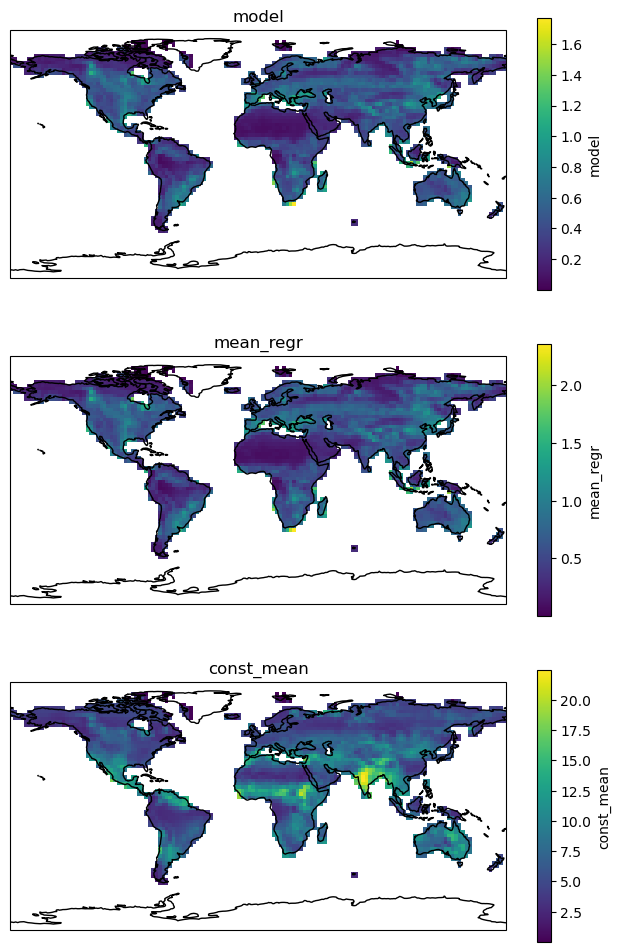

In [58]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=3,
    ncols=1,
    figsize=(8, 12)
)
depth = 0

for i, s_key in enumerate(score_keys):
    da = all_scores.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[i])
    ax[i].coastlines()
    ax[i].set_title(s_key)



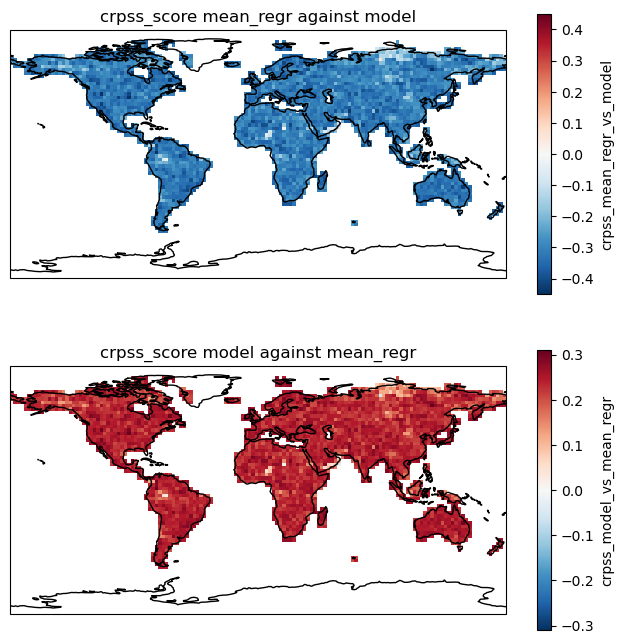

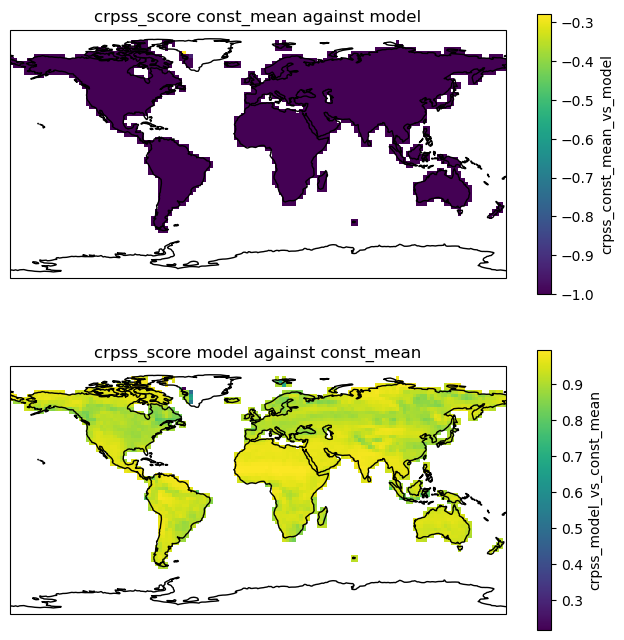

In [59]:
depth = 0

choice = "model"

for i, s_key in enumerate(score_keys):
    if s_key == choice:
        continue
    vs = model_analysis.crps_score.combine_two_crps_and_the_crpss(all_scores[choice],all_scores[s_key],choice,s_key)

    fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=2,
    ncols=1,
    figsize=(8, 8)
    )

    da = vs.isel(depth=depth)[f"crpss_{s_key}_vs_{choice}"].clip(min=-1)
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(f"crpss_score {s_key} against {choice}")

    da = vs.isel(depth=depth)[f"crpss_{choice}_vs_{s_key}"].clip(min=-1)
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title(f"crpss_score {choice} against {s_key}")

    fig_global_crpss.show()
    
